In [1]:
import pandas as pd

# Load dataset
file_path = "cleaned_dataset_no_outliers.csv"  # Ensure the file is in the same directory
df = pd.read_csv(file_path)

# Display first 5 rows to check the data
df.head()


C:\Users\mihir\AppData\Local\Temp\ipykernel_23904\795586509.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000254,254 Augusta,False,False,11.7,12.467000,0.170000,0.137000,JPL 32,2459000.5,...,0.000004,0.000040,0.000044,0.000021,6.240000e-09,1.150000e-09,0.000068,0.000005,MBA,0.40909
1,2000473,473 Nolli (1901 GC),False,False,11.7,12.394000,0.138000,0.138000,JPL 34,2459000.5,...,0.000005,0.000019,0.000029,0.000021,1.320000e-08,1.520000e-09,0.000092,0.000011,MBA,0.37280
2,2000719,719 Albert (1911 MT),True,False,15.4,7.581494,0.145937,-0.167142,JPL 214,2459000.5,...,0.000003,0.000017,0.000017,0.000003,3.910000e-09,3.310000e-10,0.000010,0.000002,AMO,0.39148
3,2000724,724 Hapag (1911 NC),False,False,13.8,9.492000,0.103000,0.198000,JPL 29,2459000.5,...,0.000005,0.000019,0.000021,0.000007,1.240000e-08,1.550000e-09,0.000026,0.000009,MBA,0.48206
4,2000728,728 Leonisis (1912 NU),False,False,12.9,5.887000,0.160000,0.481000,JPL 41,2459000.5,...,0.000003,0.000048,0.000052,0.000020,6.060000e-09,1.080000e-09,0.000069,0.000005,MBA,0.43402


In [35]:
# Save the label column separately for later comparison
labels = df["asteroid_class"]

# Display unique asteroid classes (optional)
labels.value_counts()


,count
asteroid_class,
MBA,344457
OMB,20658
MCA,2456
APO,619
AMO,346
IMB,160


In [36]:
# Drop label and non-numeric columns
drop_columns = ["asteroid_class", "asteroid_id", "asteroid_name", "orbit_solution_id", "potentially_hazardous", "near_earth_object"]
df_numeric = df.drop(columns=drop_columns, errors='ignore')

# Display first 5 rows of numeric-only data
df_numeric.head()


,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_epoch,orbit_epoch_mjd,orbit_epoch_calendar,orbital_eccentricity,semi_major_axis_au,perihelion_distance_au,...,uncertainty_perihelion_distance,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,orbit_fit_rms
0,11.7,12.467000,0.170000,0.137000,2459000.5,59000,20200531,0.122053,2.194870,1.926980,...,7.680000e-08,0.000004,0.000040,0.000044,0.000021,6.240000e-09,1.150000e-09,0.000068,0.000005,0.40909
1,11.7,12.394000,0.138000,0.138000,2459000.5,59000,20200531,0.106437,2.663625,2.380116,...,1.210000e-07,0.000005,0.000019,0.000029,0.000021,1.320000e-08,1.520000e-09,0.000092,0.000011,0.37280
2,15.4,7.581494,0.145937,-0.167142,2459000.5,59000,20200531,0.546558,2.638602,1.196452,...,5.810000e-08,0.000003,0.000017,0.000017,0.000003,3.910000e-09,3.310000e-10,0.000010,0.000002,0.39148
3,13.8,9.492000,0.103000,0.198000,2459000.5,59000,20200531,0.250901,2.454535,1.838690,...,1.270000e-07,0.000005,0.000019,0.000021,0.000007,1.240000e-08,1.550000e-09,0.000026,0.000009,0.48206
4,12.9,5.887000,0.160000,0.481000,2459000.5,59000,20200531,0.088027,2.253746,2.055355,...,6.580000e-08,0.000003,0.000048,0.000052,0.000020,6.060000e-09,1.080000e-09,0.000069,0.000005,0.43402


In [37]:
# Subsample 10,000 rows for faster processing
df_sampled = df_numeric.sample(n=20000, random_state=42)
labels_sampled = labels.loc[df_sampled.index]  # Keep corresponding labels

# Display first 5 rows of sampled data
df_sampled.head()


,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_epoch,orbit_epoch_mjd,orbit_epoch_calendar,orbital_eccentricity,semi_major_axis_au,perihelion_distance_au,...,uncertainty_perihelion_distance,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,orbit_fit_rms
169784,16.30,1.148161,0.088483,0.698569,2459000.5,59000,20200531,0.053476,2.863600,2.710467,...,1.550000e-07,0.000005,0.000062,0.000082,0.000049,2.740000e-08,2.770000e-09,0.000244,0.000024,0.47655
102582,15.90,4.202030,0.132078,0.105213,2459000.5,59000,20200531,0.351068,2.576242,1.671806,...,1.850000e-07,0.000004,0.000093,0.000093,0.000015,2.720000e-08,2.800000e-09,0.000060,0.000018,0.54789
320509,16.91,0.190182,0.055026,0.729032,2459000.5,59000,20200531,0.121153,3.078424,2.705463,...,3.630000e-07,0.000021,0.000484,0.000497,0.000106,1.040000e-07,8.250000e-09,0.000588,0.000089,0.84796
339580,16.70,1.402927,0.053729,0.729872,2459000.5,59000,20200531,0.148225,3.183013,2.711212,...,3.560000e-07,0.000009,0.000171,0.000177,0.000039,9.850000e-08,7.020000e-09,0.000232,0.000084,0.62920
141792,16.10,3.420000,0.066000,0.211000,2459000.5,59000,20200531,0.260267,2.411125,1.783589,...,1.440000e-07,0.000007,0.000042,0.000046,0.000016,1.550000e-08,2.020000e-09,0.000061,0.000010,0.62842


In [38]:
from sklearn.preprocessing import StandardScaler

# Normalize the dataset
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_sampled), columns=df_sampled.columns)

# Display first 5 rows of normalized data
df_scaled.head()


,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_epoch,orbit_epoch_mjd,orbit_epoch_calendar,orbital_eccentricity,semi_major_axis_au,perihelion_distance_au,...,uncertainty_perihelion_distance,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,orbit_fit_rms
0,0.455959,-0.885189,-0.047808,0.518697,0.134339,0.134339,0.134088,-1.162689,-0.054644,0.684358,...,-0.053597,-0.042523,-0.047005,0.021454,-0.05945,-0.063884,-0.043227,-0.019092,-0.056498,-1.226847
1,-0.047322,0.424083,1.147565,-1.520608,0.134339,0.134339,0.134088,2.588304,-1.059214,-2.199665,...,-0.053597,-0.042523,-0.047005,0.021454,-0.05945,-0.063884,-0.043227,-0.019092,-0.056498,-0.279134
2,1.223461,-1.295899,-0.965211,0.623395,0.134339,0.134339,0.134088,-0.309650,0.696355,0.670464,...,-0.053597,-0.042521,-0.046998,0.021454,-0.05945,-0.063884,-0.043227,-0.019092,-0.056498,3.707133
3,0.959239,-0.775964,-1.000765,0.626280,0.134339,0.134339,0.134088,0.031570,1.061985,0.686427,...,-0.053597,-0.042523,-0.047003,0.021454,-0.05945,-0.063884,-0.043227,-0.019092,-0.056498,0.801026
4,0.204319,0.088806,-0.664302,-1.157030,0.134339,0.134339,0.134088,1.443806,-1.636442,-1.889280,...,-0.053597,-0.042523,-0.047005,0.021454,-0.05945,-0.063884,-0.043227,-0.019092,-0.056498,0.790664


In [39]:
# Reattach asteroid_class labels (for reference only, clustering will be unsupervised)
df_scaled["asteroid_class"] = labels_sampled.values

# Display first 5 rows with asteroid_class for later comparison
df_scaled.head()


,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_epoch,orbit_epoch_mjd,orbit_epoch_calendar,orbital_eccentricity,semi_major_axis_au,perihelion_distance_au,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,orbit_fit_rms,asteroid_class
0,0.455959,-0.885189,-0.047808,0.518697,0.134339,0.134339,0.134088,-1.162689,-0.054644,0.684358,...,-0.042523,-0.047005,0.021454,-0.05945,-0.063884,-0.043227,-0.019092,-0.056498,-1.226847,MBA
1,-0.047322,0.424083,1.147565,-1.520608,0.134339,0.134339,0.134088,2.588304,-1.059214,-2.199665,...,-0.042523,-0.047005,0.021454,-0.05945,-0.063884,-0.043227,-0.019092,-0.056498,-0.279134,MBA
2,1.223461,-1.295899,-0.965211,0.623395,0.134339,0.134339,0.134088,-0.309650,0.696355,0.670464,...,-0.042521,-0.046998,0.021454,-0.05945,-0.063884,-0.043227,-0.019092,-0.056498,3.707133,MBA
3,0.959239,-0.775964,-1.000765,0.626280,0.134339,0.134339,0.134088,0.031570,1.061985,0.686427,...,-0.042523,-0.047003,0.021454,-0.05945,-0.063884,-0.043227,-0.019092,-0.056498,0.801026,MBA
4,0.204319,0.088806,-0.664302,-1.157030,0.134339,0.134339,0.134088,1.443806,-1.636442,-1.889280,...,-0.042523,-0.047005,0.021454,-0.05945,-0.063884,-0.043227,-0.019092,-0.056498,0.790664,MBA


# apply pca

In [40]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions to 3
pca = PCA(n_components=3)
df_pca = pd.DataFrame(pca.fit_transform(df_scaled.drop(columns=["asteroid_class"])), columns=["PC1", "PC2", "PC3"])

# Display first 5 rows of transformed data
df_pca.head()


,PC1,PC2,PC3
0,0.526965,0.213948,-0.390357
1,-3.833093,-2.467820,0.234145
2,2.129572,0.478243,0.822292
3,2.212791,1.281751,-0.548062
4,-3.848243,-2.446318,0.422501


In [41]:
# Check variance explained by each principal component
explained_variance = pca.explained_variance_ratio_

# Display variance retained by each principal component
explained_variance


array([0.22913577, 0.20090557, 0.10240783])

In [42]:
# Compute cumulative variance retained
cumulative_variance = explained_variance.cumsum()

# Display cumulative variance
cumulative_variance


array([0.22913577, 0.43004134, 0.53244917])

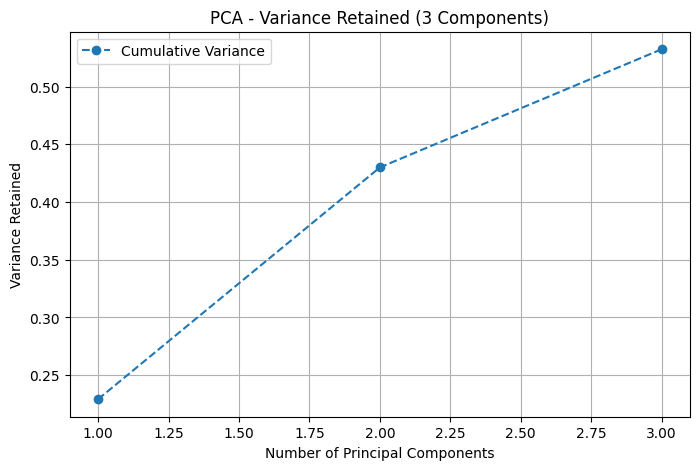

In [43]:
import matplotlib.pyplot as plt

# Plot cumulative variance retained
plt.figure(figsize=(8,5))
plt.plot(range(1, 4), cumulative_variance, marker='o', linestyle='--', label="Cumulative Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Variance Retained")
plt.title("PCA - Variance Retained (3 Components)")
plt.grid(True)
plt.legend()
plt.show()


In [44]:
# Apply PCA without limiting components
pca_full = PCA().fit(df_scaled.drop(columns=["asteroid_class"]))

# Compute cumulative variance retained
cumulative_variance_full = pca_full.explained_variance_ratio_.cumsum()

# Find number of components needed for 95% variance
num_components_95 = (cumulative_variance_full >= 0.95).argmax() + 1

# Display result
num_components_95


15

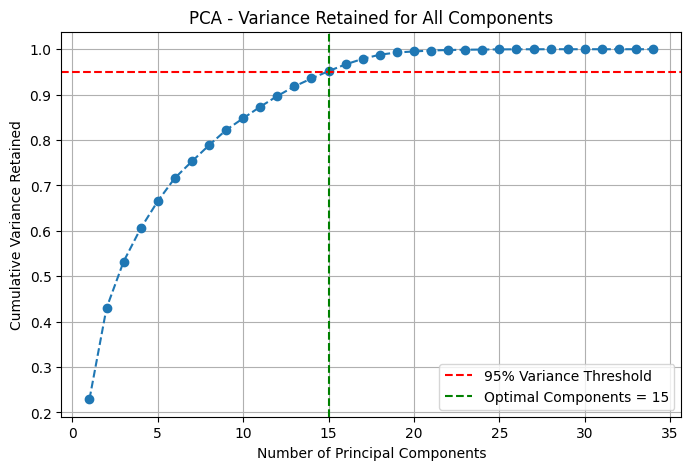

In [45]:
# Plot cumulative variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance_full)+1), cumulative_variance_full, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='--', label="95% Variance Threshold")
plt.axvline(x=num_components_95, color='g', linestyle='--', label=f"Optimal Components = {num_components_95}")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Retained")
plt.title("PCA - Variance Retained for All Components")
plt.legend()
plt.grid(True)
plt.show()


In [61]:
# Apply PCA with 7 components (balances speed & accuracy)
pca_optimal = PCA(n_components=15)
df_pca_optimal = pd.DataFrame(pca_optimal.fit_transform(df_scaled.drop(columns=["asteroid_class"])), columns=[f"PC{i+1}" for i in range(15)])

# Display first 5 rows
df_pca_optimal.head()
df_pca_optimal.shape


(20000, 15)

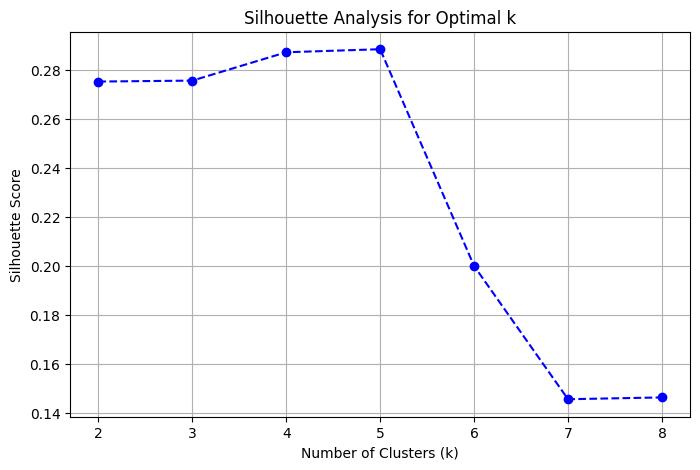

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test different values of k
k_values = [2, 3, 4, 5, 6]
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca_optimal)
    sil_scores.append(silhouette_score(df_pca_optimal, labels))

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.grid(True)
plt.show()


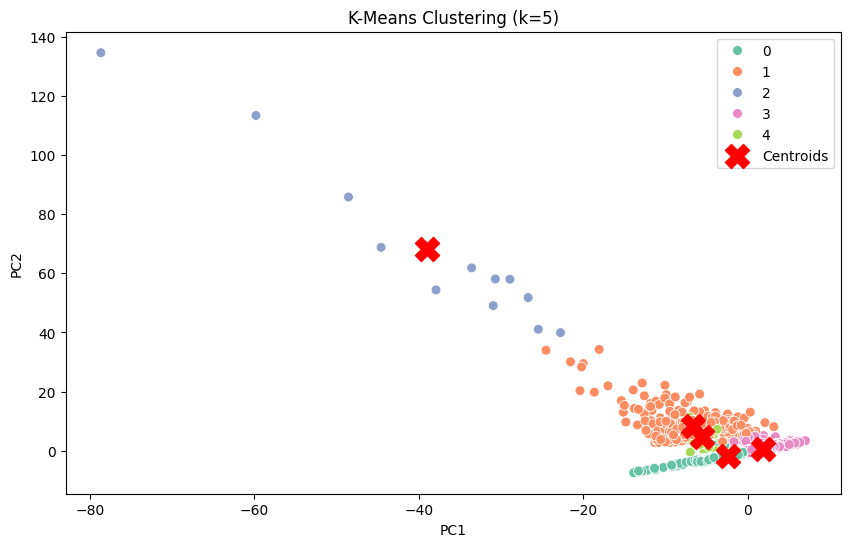

In [63]:
# Choose the best k from the silhouette plot (adjust manually based on output)
optimal_k = k_values[np.argmax(sil_scores)]

# Run K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pca_optimal["Cluster_KMeans"] = kmeans.fit_predict(df_pca_optimal)

# Plot K-Means Clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=df_pca_optimal["PC1"], y=df_pca_optimal["PC2"], hue=df_pca_optimal["Cluster_KMeans"], palette="Set2", s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker="X", label="Centroids")
plt.legend()
plt.title(f"K-Means Clustering (k={optimal_k})")
plt.show()


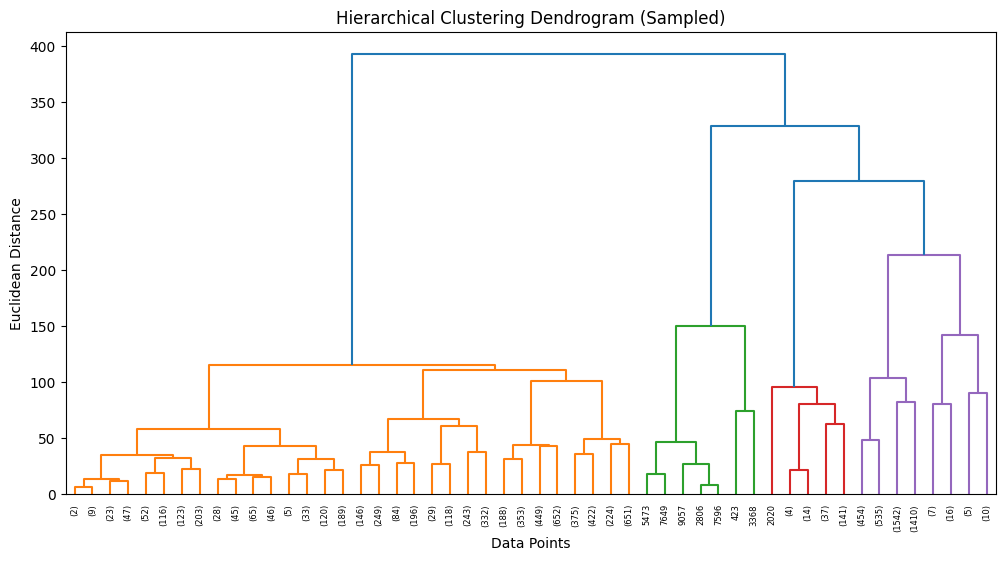

In [64]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Sample 5000 rows for efficiency
df_sample = df_pca_optimal.sample(n=10000, random_state=42)

# Generate linkage matrix for dendrogram
linked = linkage(df_sample, method="ward")

# Plot dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram (Sampled)")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()


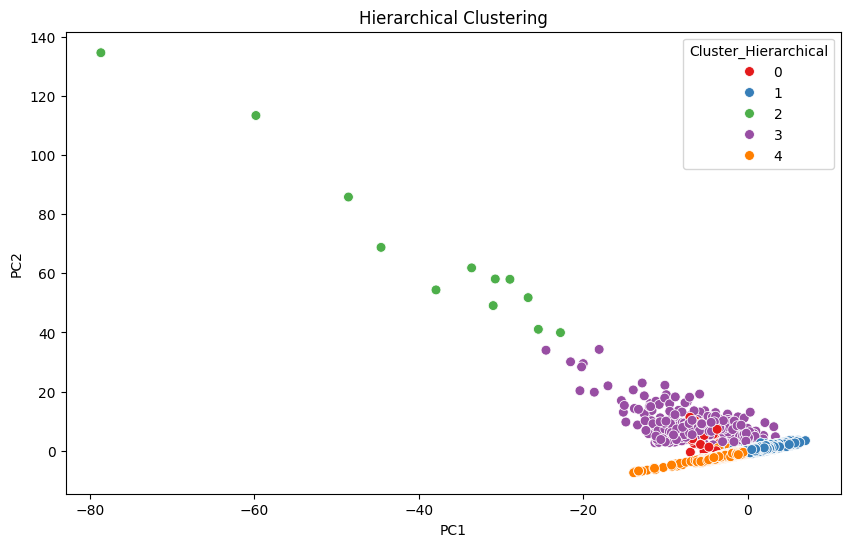

In [65]:
from sklearn.cluster import AgglomerativeClustering

# Run Agglomerative Clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
df_pca_optimal["Cluster_Hierarchical"] = hierarchical.fit_predict(df_pca_optimal)

# Plot Hierarchical Clustering Results
plt.figure(figsize=(10,6))
sns.scatterplot(x=df_pca_optimal["PC1"], y=df_pca_optimal["PC2"], hue=df_pca_optimal["Cluster_Hierarchical"], palette="Set1", s=50)
plt.title("Hierarchical Clustering")
plt.show()


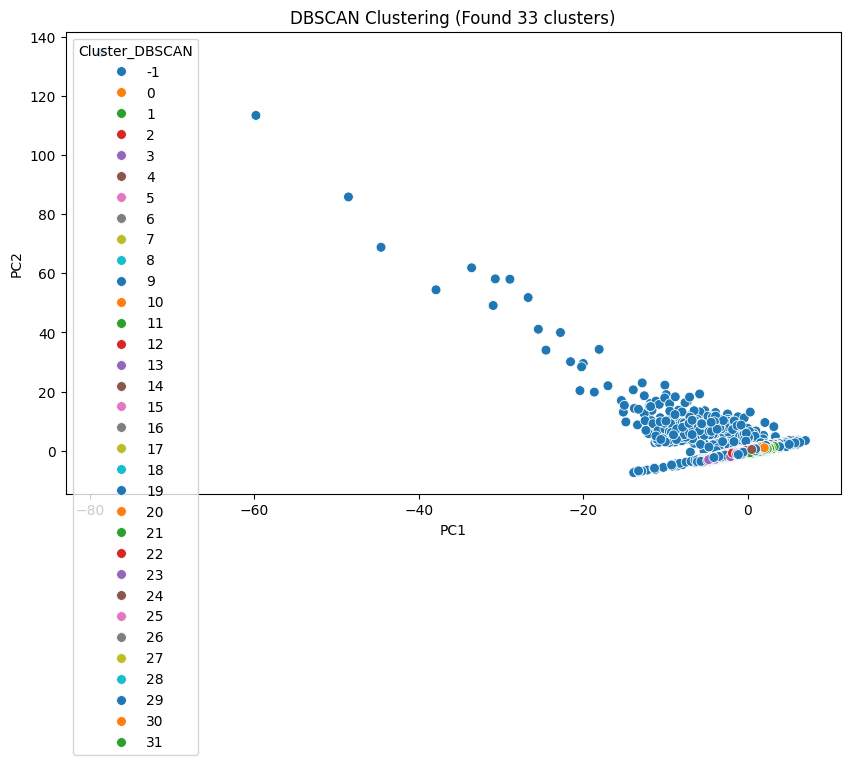

In [68]:
# Adjust DBSCAN parameters for better clustering
eps_value = 1.5  # Increase to merge small clusters
min_samples_value = 10  # Filter out noise

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
df_pca_optimal["Cluster_DBSCAN"] = dbscan.fit_predict(df_pca_optimal)

# Count clusters
num_clusters_dbscan = len(set(df_pca_optimal["Cluster_DBSCAN"])) - (1 if -1 in df_pca_optimal["Cluster_DBSCAN"] else 0)

# Plot DBSCAN Clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=df_pca_optimal["PC1"], y=df_pca_optimal["PC2"], hue=df_pca_optimal["Cluster_DBSCAN"], palette="tab10", s=50)
plt.title(f"DBSCAN Clustering (Found {num_clusters_dbscan} clusters)")
plt.show()


In [74]:
# Check data types
print(df_pca_optimal.dtypes)

# Check unique values in True_Class
print("Unique values in True_Class:", df_pca_optimal["True_Class"].unique())

# Check unique values in Cluster_KMeans
print("Unique values in Cluster_KMeans:", df_pca_optimal["Cluster_KMeans"].unique())


PC1                     float64
PC2                     float64
PC3                     float64
PC4                     float64
PC5                     float64
PC6                     float64
PC7                     float64
PC8                     float64
PC9                     float64
PC10                    float64
PC11                    float64
PC12                    float64
PC13                    float64
PC14                    float64
PC15                    float64
Cluster_KMeans            int32
Cluster_Hierarchical      int64
Cluster_DBSCAN            int64
True_Class               object
True_Class_Encoded        int64
dtype: object
Unique values in True_Class: ['MBA' 'OMB' 'MCA' 'APO' 'AMO' 'IMB']
Unique values in Cluster_KMeans: [3 0 1 4 2]


In [69]:
# Reattach the original asteroid_class labels
df_pca_optimal["True_Class"] = labels_sampled.values

# Display first 5 rows to verify
df_pca_optimal.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,Cluster_KMeans,Cluster_Hierarchical,Cluster_DBSCAN,True_Class
0,0.526965,0.213948,-0.390357,-1.429111,0.795776,1.084779,0.941739,-1.183521,2.126244,0.589149,0.600549,-0.422861,0.477857,0.263706,-0.196219,3,1,0,MBA
1,-3.833093,-2.467820,0.234145,2.216909,-0.964540,-1.002499,0.880557,-1.250574,-0.369731,-1.380863,-1.696443,-1.549403,0.404844,-0.168140,0.142989,0,4,-1,MBA
2,2.129572,0.478243,0.822292,-0.582950,3.079864,-1.100958,-0.690365,0.599378,-0.014843,-0.649090,-2.556190,0.262288,-1.027786,-0.735965,0.064504,3,1,-1,MBA
3,2.212791,1.281751,-0.548062,0.503874,1.464098,-0.322063,0.629147,-1.117677,1.399491,-0.214891,-1.327206,-0.533581,-0.055362,-0.233859,-0.094661,3,1,0,MBA
4,-3.848243,-2.446318,0.422501,1.068982,0.366201,-0.958770,-1.092117,0.711831,1.030756,0.112459,-0.508167,0.646048,-0.430823,-0.152352,0.198460,0,4,3,MBA


In [71]:
from sklearn.preprocessing import LabelEncoder

# Convert asteroid_class (True_Class) to numerical values
label_encoder = LabelEncoder()
df_pca_optimal["True_Class_Encoded"] = label_encoder.fit_transform(df_pca_optimal["True_Class"])

# Verify transformation
df_pca_optimal[["True_Class", "True_Class_Encoded"]].head()


,True_Class,True_Class_Encoded
0,MBA,3
1,MBA,3
2,MBA,3
3,MBA,3
4,MBA,3


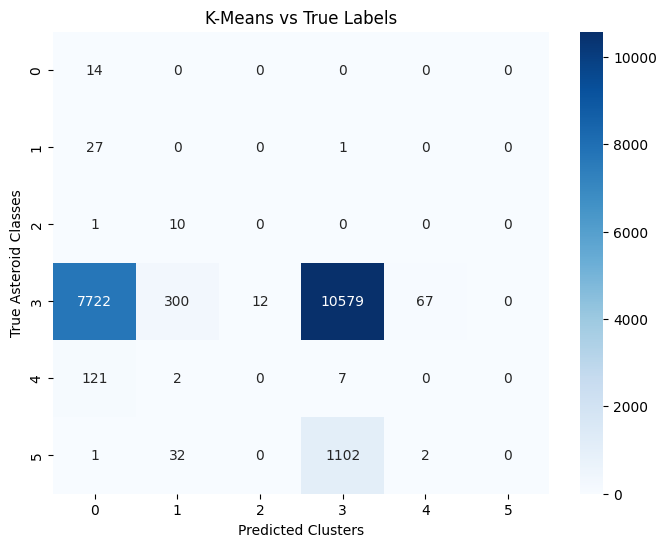

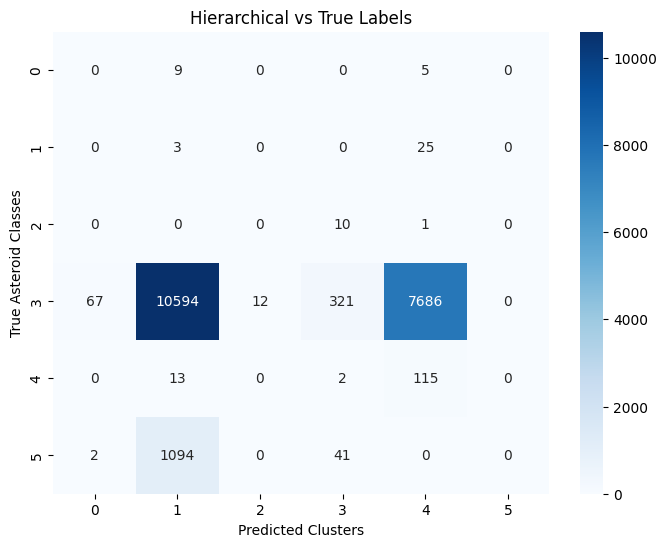

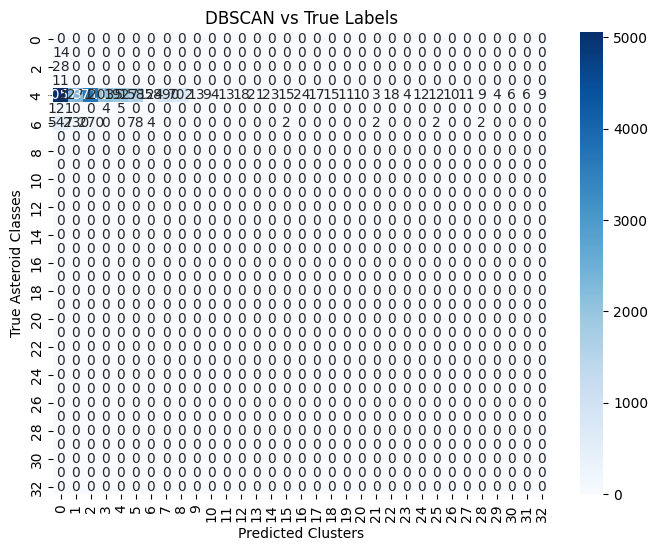

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(true_labels, predicted_labels, title):
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Clusters")
    plt.ylabel("True Asteroid Classes")
    plt.title(title)
    plt.show()

# Compare K-Means clusters with True Labels
plot_confusion_matrix(df_pca_optimal["True_Class_Encoded"], df_pca_optimal["Cluster_KMeans"], "K-Means vs True Labels")

# Compare Hierarchical clusters with True Labels
plot_confusion_matrix(df_pca_optimal["True_Class_Encoded"], df_pca_optimal["Cluster_Hierarchical"], "Hierarchical vs True Labels")

# Compare DBSCAN clusters with True Labels
plot_confusion_matrix(df_pca_optimal["True_Class_Encoded"], df_pca_optimal["Cluster_DBSCAN"], "DBSCAN vs True Labels")



In [79]:
import numpy as np

def cluster_purity(true_labels, predicted_labels):
    contingency_matrix = confusion_matrix(true_labels, predicted_labels)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

# Compute purity for each clustering method
purity_kmeans = cluster_purity(df_pca_optimal["True_Class_Encoded"], df_pca_optimal["Cluster_KMeans"])
purity_hierarchical = cluster_purity(df_pca_optimal["True_Class_Encoded"], df_pca_optimal["Cluster_Hierarchical"])
purity_dbscan = cluster_purity(df_pca_optimal["True_Class_Encoded"], df_pca_optimal["Cluster_DBSCAN"])

# Display results
print(f"K-Means Cluster Purity: {purity_kmeans:.4f}")
print(f"Hierarchical Cluster Purity: {purity_hierarchical:.4f}")
print(f"DBSCAN Cluster Purity: {purity_dbscan:.4f}")



K-Means Cluster Purity: 0.9340
Hierarchical Cluster Purity: 0.9340
DBSCAN Cluster Purity: 0.9340
